# Sistemas de ecuaciones

Consideremos el sistema:

$$x + y =3$$
$$3x - 4y = 2$$

Desde el punto de vista geomético la solución a este sistema es el punto de corte entre ambas rectas

<center>

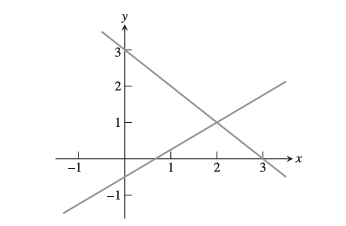

<center>

Para resolver este sistema es posible hacer uso del algoritmo de **eliminación gaussiana**. Se busca llevar la parte de la matriz que contiene los coeficientes del sistema de ecuaciones lineales a una forma triangular superior. Luego solo debe sustituirse hacia atrás

La etapa de eliminación consiste en conseguir los ceros de la parte inferior de la matriz, esto toma

```
for j in range(n-1):
        poner ceros en cada columna j
````

Ahora, hacer esta operación para cada columna implica, por ejemplo para la primera columna, poner ceros en $a_{21},...a_{n1}$

```
for j in range(n-1):
        for i in range(j+1, n):
                eliminar entrada a(i,j)
````

Las entradas princiales de cada columna que no son cero se denominan pivotes.

Eliminar cada entrada $a_{in}$ requiere 2n + 1 operaciones (una división, una n multiplicaciones y n sumas)

Hacerlo para cada columna requiere hacerlo n - 1 veces.

<center>

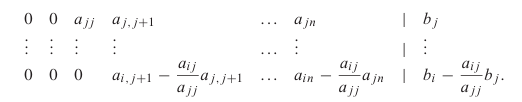

<center>




Considerando podemos ahorrarnos las operaciones por cero, necesitamos para cada elemento $a_{ij}$, una división, n - j + 1 multiplicaciones y n - j + 1 sumas/restas.

In [35]:
import numpy as np

# Por el momento no se consideran intercambios de filas
# Matrices de n ecuaciones y n incognitas

matriz = np.array([[2,2,3],[2,4,3],[1,2,3]], dtype = float)
b = np.array([[2],[1],[4]], dtype=float)

n = matriz.shape[1]-1

for j in range(n):
    if abs(matriz[j,j]) < 1e-15:
        print('Error pivote cero')
        break
    
    for i in range(j+1, n + 1):
        print(i,j+1)
        
        mult = matriz[i,j]/matriz[j,j]
        
        # Aunque esta parte parezca un error
        # Hacerlo de esta manera es eficiente puesto que no necesitamos
        # Hacer ninguna operación sobre el elemento a_ij posteriormente
        
        matriz[i,j+1:] = matriz[i,j+1:] - mult*matriz[j,j+1:]

        
        b[i] = b[i] - mult*b[j]

print(matriz)
print(b)



1 1
2 1
2 2
[[2.  2.  3. ]
 [2.  2.  0. ]
 [1.  1.  1.5]]
[[ 2. ]
 [-1. ]
 [ 3.5]]


In [36]:
sol = np.zeros((n+1,1))

for i in range(n,-1,-1):
    sol[i] = b[i]

    for j in range(n,i,-1):

        sol[i] -= matriz[i,j]*sol[j]

    sol[i] = sol[i]/matriz[i,i]



print(sol)

[[-2.        ]
 [-0.5       ]
 [ 2.33333333]]


El número total de operaciones necesarias para la eliminación es de 

$$\sum_{j=1}^{n-1} \sum_{i=1}^{j} 2(j+1)+1 = \frac{2}{3}n^3 + \frac{1}{2}n^2 - \frac{7}{6}n \approx \frac{2}{3}n^3$$

Al terminar obtenemos el siguiente sistema:

<center>

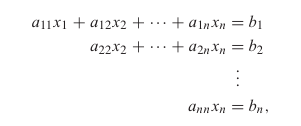

<center>

Para obtener las soluciones con sustitución hacia atrás:

$$x_n = \frac{b_n}{a_{nn}}$$
Y sustituyendo hasta:
$$x_1 = \frac{b_1 - a_{1n}x_n - ... - a_{12}x_2}{a_{11}}$$

La cantidad de operaciones son:

$$1 + 3 + 5 + ... + (2n - 1) = \sum_{i = 1}^n 2i - 1 = n^2$$

En conclusión podríamos decir que la eliminación gaussiana toma aproximadamente $\frac{2}{3}n^3$ operaciones o en notación de Big O, O(n^3)